In [1]:
import torch
from equiv_dens.training.parse_command_line_arguments import parse_command_line_arguments
from equiv_dens.training.errors import ErrorDict
from equiv_dens.data.density_dataset import AtomsDensityData
from equiv_dens.data.hamiltonian_dataset import seeded_random_split
from equiv_dens.utils.grids import cubical_grid, cubical_sampling,\
    dftpy_grid, CubicalGrid, spherical_grid, spherical_radial_sampling
from equiv_dens.training.model_loader import load_model
import equiv_dens.utils.base as utils
from equiv_dens.utils import orbitals
from functools import partial
import os
import numpy as np
import equiv_dens.scripts.transform_df_coeffs as transform_df_coeffs

%load_ext autoreload
%autoreload 2

Use "numpy" for Fourier Transform


/home/mihail/anaconda3/envs/equiv_dens/lib/python3.7/site-packages/pyscf/lib/misc.py:47: H5pyDeprecationWarning: Using default_file_mode other than 'r' is deprecated. Pass the mode to h5py.File() instead.
  h5py.get_config().default_file_mode = 'a'


In [6]:
args, hyperparam_args = parse_command_line_arguments(arg_file='C_dens.txt')

print('type dtype', type(args.dtype))
args.fix_arguments = True
print('args np dir', args.np_dataset)
# no restart directory specified
directory = args.restart  # load directory name
# load latest checkpoint
checkpoint_path = os.path.join(directory, 'checkpoints')  # checkpoint directory
checkpoint = torch.load(os.path.join(
    checkpoint_path, 'latest_checkpoint.pth'), map_location='cpu')
latest_checkpoint = checkpoint['step']
model_code = checkpoint['ID']  # load ID
step = checkpoint['step']
for arg in vars(checkpoint['args']):
    if args.fix_arguments:
        if arg in hyperparam_args:
            print('loading hyperparam arg', arg)
            setattr(args, arg, getattr(checkpoint['args'], arg))
    else:
        print('loading all arg', arg)
        setattr(args, arg, getattr(checkpoint['args'], arg))
restore = True

args.best_model_path = 'best_' + model_code + '.pth'
print('best_model_path', args.best_model_path)

print('model code:', model_code)
# determine whether GPU is used for training
print('args use gpu', args.use_gpu)
args.use_gpu = False
# load dataset(s)
print("loading density from" + str(args.dens_dataset) + "...")
print("loading atoms from" + args.np_dataset + "...")

args.radial_coeffs_file = 'datasets/augccpvqzjkfit_radial_coeffs_libcint_df.npy'

args.verbose = 0
args.use_gpu = False
args.cube_grid = True 
args.radii_adjust = True 
args.expansion_constraint=None
if args.cube_grid:
    args.cube_origin = -0.25
    args.cube_extent = 0.5
    args.cube_size = 50
    args.radii_adjust = False
    grid_origin = args.cube_origin
    grid_extent = np.array([args.cube_extent] * 3)
    grid_fn = partial(cubical_grid, nx=args.cube_size, ny=args.cube_size, nz=args.cube_size,
                      extent=grid_extent,
                      origin=np.array([grid_origin] * 3))
    sampling_fn = cubical_sampling
else:
    args.spherical_grid_level = 6
    grid_fn = partial(spherical_grid, level=args.spherical_grid_level)
    sampling_fn = partial(spherical_radial_sampling, rotate=False)
    grid_origin = 0
    grid_extent = None

    
dataset = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density', 'df_coeffs'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=torch.float32,
                           grid_fn=grid_fn,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           verbose=0,
                           radii_adjust=args.radii_adjust)

dataset_df = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density', 'df_coeffs'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=torch.float32,
                           grid_fn=grid_fn,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           verbose=0,
                           radii_adjust=args.radii_adjust,
                           projected_density=True)
    
#dataset_df.density_fitting[0]['df_coeff'] *= 0
sample = dataset.get_properties([0])
sample_df = dataset_df.get_properties([0])
print('density loss', torch.sum(torch.abs(sample['density'] - sample_df['density']) * sample['coord_weights'])/sample['atom_numbers'])
print('density integral', torch.sum(sample['density'] * sample['coord_weights']))
print('df integral', torch.sum(sample_df['density'] * sample['coord_weights']))
print(dataset_df.density_fitting)
print(dataset.atoms)
args.restart = None
args.integral_constraint = None
args.expansion_constraint = None
args.timing = False
model = load_model(args, dataset)
result = model(sample)
print('ml density loss', torch.sum(torch.abs(sample['density'] - result['density']) * sample['coord_weights'])/sample['atom_numbers'])
print('ml density integral', torch.sum(result['density'] * sample['coord_weights']))


type dtype <class 'torch.dtype'>
args np dir datasets/C_augccpvdz.npy
loading hyperparam arg activation
loading hyperparam arg order
loading hyperparam arg mixing_order
loading hyperparam arg order_en
loading hyperparam arg mixing_order_en
loading hyperparam arg num_features
loading hyperparam arg num_basis_functions
loading hyperparam arg num_radial_components
loading hyperparam arg num_energy_features
loading hyperparam arg num_modules
loading hyperparam arg num_residual_pre_x
loading hyperparam arg num_residual_post_x
loading hyperparam arg num_residual_pre_vi
loading hyperparam arg num_residual_pre_vj
loading hyperparam arg num_residual_post_v
loading hyperparam arg num_residual_output
loading hyperparam arg num_energy_output
loading hyperparam arg basis_functions
loading hyperparam arg cutoff
loading hyperparam arg orthonormal_basis
loading hyperparam arg expansion_constraint
loading hyperparam arg integral_constraint
loading hyperparam arg integral_scale
loading hyperparam arg in

In [7]:
sample_idx = 0
bas_idx = 5
for bas_idx in range(dataset_df.density_fitting['df_coeffs'][sample_idx].shape[0]):
    print('bas_idx', bas_idx)
    # dataset_df.density_fitting['df_coeffs'][sample_idx] = torch.tensor(dataset_df.density_fitting['df_coeffs'][sample_idx]).to(sample['positions']).view(1, -1)
    dataset_df.density_fitting['df_coeffs'][sample_idx] *= 0
    dataset_df.density_fitting['df_coeffs'][sample_idx, bas_idx] = 1 

    sample_df = dataset_df.get_properties([sample_idx])
    df_abs_integral =  torch.sum(torch.abs(sample_df['density']) * sample_df['coord_weights'])
    print('df abs integral', df_abs_integral)
    print('df density max', torch.max(sample_df['density']))
    
    permuted_coeffs = transform_df_coeffs.transform(sample_df['df_coeffs'], sample_df['atom_numbers'])

    coeffs = orbitals.vector_to_coeffs_dict({'spherical_coeffs': permuted_coeffs}, model.density_repr_model[0].orbital_basis,
                                             result['atom_numbers'], radial_coeffs=False)
    sample['spherical_coeffs'] = coeffs['spherical_coeffs']
    sample['radial_width'] = [{key:torch.zeros_like(result['radial_width'][i][key]) for key in result['radial_width'][i].keys()} for i in range(len(result['radial_width']))]
    sample['radial_scale'] = [{key:torch.zeros_like(result['radial_scale'][i][key]) for key in result['radial_scale'][i].keys()} for i in range(len(result['radial_scale']))]
    # sample['radial_scale'] = result['radial_scale']
    res = model.property_models['density'](sample)

    #mol = dataset_df.mols[sample_idx]
    #if not mol._built and mol.basis != dataset_df.density_fitting[sample_idx]['auxbasis']:
    #    mol.basis = self.density_fitting[sample_idx]['auxbasis']
    #    # build_start = time.time()
    #    mol.build()
    #ctr_coeff = mol._libcint_ctr_coeff(bas_idx)
    #print('mol_env', mol._env)
    #print('contracted coeff', ctr_coeff)
    #print('density shape', res['density'].shape)
    res_density = res['density']
    #res_density = res['density']
    ml_abs_integral = torch.sum(torch.abs(res_density) * sample_df['coord_weights'])
    print('ml abs integral', ml_abs_integral)
    print('ml density max', torch.max(res_density))
    ratio = ml_abs_integral/df_abs_integral
    print('ratio', float(ratio))
    print('density diff', torch.mean(torch.abs(res_density - sample_df['density']) * sample['coord_weights']))

bas_idx 0
df abs integral tensor(0.0194)
df density max tensor(100.7283)
ml abs integral tensor(0.0194, dtype=torch.float64)
ml density max tensor(100.7284, dtype=torch.float64)
ratio 1.000000153431598
density diff tensor(3.3039e-14, dtype=torch.float64)
bas_idx 1
df abs integral tensor(0.0444)
df density max tensor(54.1518)
ml abs integral tensor(0.0444, dtype=torch.float64)
ml density max tensor(54.1518, dtype=torch.float64)
ratio 1.000000130547024
density diff tensor(6.9082e-14, dtype=torch.float64)
bas_idx 2
df abs integral tensor(0.1019)
df density max tensor(25.2566)
ml abs integral tensor(0.1019, dtype=torch.float64)
ml density max tensor(25.2566, dtype=torch.float64)
ratio 1.0000002708197917
density diff tensor(2.2341e-13, dtype=torch.float64)
bas_idx 3
df abs integral tensor(0.2044)
df density max tensor(12.8491)
ml abs integral tensor(0.2044, dtype=torch.float64)
ml density max tensor(12.8491, dtype=torch.float64)
ratio 1.0000003022725117
density diff tensor(5.1712e-13, dtype

In [ ]:
df_coeffs = torch.tensor(dataset_df.density_fitting[sample_idx]['df_coeff']).to(sample['positions']).view(1, -1)
print(df_coeffs)
df_coeffs_canon =  transform_df_coeffs.transform(df_coeffs, sample_df['atom_numbers'])
print(df_coeffs_canon)
print(transform_df_coeffs.transform_back(df_coeffs_canon, sample_df['atom_numbers']))

In [ ]:
import pyscf
print(pyscf.lib.param.BOHR)
print(pyscf.lib.param.)

In [ ]:
print(utils.to_angstrom)

In [ ]:
print(sample['coord_weights'])
print(sample_df['coord_weights'])
print(sample['coords'])
print(sample_df['coords'])

In [ ]:
(1-0.9927)/11000

In [ ]:
print('df max', torch.max(sample_df['density']))
print('pred max', torch.max(res_density))
print('ratio max', torch.max(res_density)/torch.max(sample_df['density']))
print('df 10', sample_df['density'][:, 10])
print('pred 10', res_density[:, 10])
print('pred 10', res_density[:, 10])
print('ratio 10', res_density[:, 10]/sample_df['density'][:, 10])
print('df 1000', sample_df['density'][:, 1000])
print('pred 1000', res_density[:, 1000])
print('pred 1000', res_density[:, 1000])
print('ratio 1000', res_density[:, 1000]/sample_df['density'][:, 1000])

In [ ]:
sample_idx = 0
#bas_idx = 141
dataset_df.density_fitting[sample_idx]['df_coeff'] = torch.tensor(dataset_df.density_fitting[sample_idx]['df_coeff']).to(sample['positions']).view(1, -1)
#dataset_df.density_fitting[sample_idx]['df_coeff'] *= 0
#dataset_df.density_fitting[sample_idx]['df_coeff'] += 1 

sample_df = dataset_df.get_properties([sample_idx])
df_abs_integral =  torch.sum(torch.abs(sample_df['density']) * sample_df['coord_weights'])
print('df abs integral', df_abs_integral)

#permuted_coeffs = dataset_df.density_fitting[sample_idx]['df_coeff']
print('original coeffs', dataset_df.density_fitting[sample_idx]['df_coeff'])

permuted_coeffs = transform_df_coeffs.transform(dataset_df.density_fitting[sample_idx]['df_coeff'], sample_df['atom_numbers'])
print('permuted coeffs', permuted_coeffs)
#dataset_df.density_fitting[sample_idx]['df_coeff'] = torch.tensor(dataset_df.density_fitting[sample_idx]['df_coeff']).to(sample['positions']).view(1, -1)
#dataset_df.density_fitting[sample_idx]['df_coeff'] *= 0
#dataset_df.density_fitting[sample_idx]['df_coeff'][:, 10] = 1 

coeffs = orbitals.vector_to_coeffs_dict({'spherical_coeffs': permuted_coeffs}, model.density_repr_model[0].orbital_basis,
                                         result['atom_numbers'], radial_coeffs=False)
sample = dataset.get_properties([sample_idx])
sample['spherical_coeffs'] = coeffs['spherical_coeffs']
sample['radial_width'] = [{key:torch.zeros_like(result['radial_width'][i][key]) for key in result['radial_width'][i].keys()} for i in range(len(result['radial_width']))]
sample['radial_scale'] = [{key:torch.zeros_like(result['radial_scale'][i][key]) for key in result['radial_scale'][i].keys()} for i in range(len(result['radial_scale']))]
# sample['radial_scale'] = result['radial_scale']
res = model.property_models['density'](sample)

#mol = dataset_df.mols[sample_idx]
#if not mol._built and mol.basis != dataset_df.density_fitting[sample_idx]['auxbasis']:
#    mol.basis = self.density_fitting[sample_idx]['auxbasis']
#    # build_start = time.time()
#    mol.build()
#ctr_coeff = mol._libcint_ctr_coeff(10)
#print('contracted coeff', ctr_coeff)
#print('contracted coeff 10', mol._libcint_ctr_coeff(10))
#print('contracted coeff 11', mol._libcint_ctr_coeff(11))
#print('contracted coeff 12', mol._libcint_ctr_coeff(12))
#print('density shape', res['density'].shape)
#ratio_factor = 3.5449070930480957
#res_density = res['density'] * float(ctr_coeff) / ratio_factor
res_density = res['density']
ml_abs_integral = torch.sum(torch.abs(res_density) * sample_df['coord_weights'])
print('ml abs integral', ml_abs_integral)
ratio = ml_abs_integral/df_abs_integral
print('abs ratio', float(ratio))
print('density diff', torch.mean(torch.abs(res_density - sample_df['density']) * sample['coord_weights']) / df_abs_integral)
print('pred min idx', torch.argmin(torch.abs(res_density)), '; df min idx', torch.argmin(torch.abs(sample_df['density'])))
print('pred max idx', torch.argmax(torch.abs(res_density)), '; df max idx', torch.argmax(torch.abs(sample_df['density'])))
print('pred min', torch.min(torch.abs(res_density)), '; df min', torch.min(torch.abs(sample_df['density'])))
print('pred max', torch.max(torch.abs(res_density)), '; df max', torch.max(torch.abs(sample_df['density'])))
print('ratio max', float(torch.max(res_density)/torch.max(sample_df['density'])))
print('density diff max', torch.abs(torch.max(res_density) - torch.max(sample_df['density'])))
point = 61225
print('ratio', str(point), float(res_density[:, point]/sample_df['density'][:, point]))
print('density diff', str(point), torch.abs(res_density[:, point] - sample_df['density'][:, point]))
print('df', str(point), sample_df['density'][:, point])
print('ml', str(point), res_density[:, point])
print('coords', sample_df['coords'])
print('coord weights', sample_df['coord_weights'])

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131)
x, y  = np.meshgrid(np.arange(50), np.arange(50))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 23
idx = np.ravel_multi_index((x_f, y_f, z_f), (50, 50, 50))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
dens2d = res_density.squeeze().detach().cpu().numpy()[idx]
dens2d = dens2d.reshape(50, 50)

indices = np.stack((x_f, y_f, z_f), axis=1)
coords_space = sample['coords']
print('coords space shape', coords_space.shape)
vmin = np.min(dens2d)
vmax = np.max(dens2d)
c1 = ax1.contourf(x, y, dens2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')
print(result['density'].shape)

p_dens = sample_df['density'].squeeze()

p_dens = p_dens[idx].reshape(50, 50)
vmin = np.min(p_dens.numpy())
vmax = np.max(p_dens.numpy())

ax2 = fig.add_subplot(132)
c2 = ax2.contourf(x, y, p_dens, vmin=vmin, vmax=vmax, levels=100)
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
c3 = ax3.contourf(x, y, p_dens-dens2d, vmin=vmin, vmax=vmax, levels=100)
ax3.set_aspect('equal')

fig.colorbar(c2, ax=[ax1, ax2])
fig.colorbar(c3, ax=[ax3])
#plt.savefig('figures/target_vs_result.pdf', dpi=300)
plt.show()

In [8]:

args, hyperparam_args = parse_command_line_arguments(arg_file='ethanol_dens_001_mae.txt')

print('type dtype', type(args.dtype))
args.fix_arguments = True
print('args np dir', args.np_dataset)
# no restart directory specified
directory = args.restart  # load directory name
# load latest checkpoint
checkpoint_path = os.path.join(directory, 'checkpoints')  # checkpoint directory
checkpoint = torch.load(os.path.join(
    checkpoint_path, 'latest_checkpoint.pth'), map_location='cpu')
latest_checkpoint = checkpoint['step']
model_code = checkpoint['ID']  # load ID
step = checkpoint['step']
for arg in vars(checkpoint['args']):
    if args.fix_arguments:
        if arg in hyperparam_args:
            print('loading hyperparam arg', arg)
            setattr(args, arg, getattr(checkpoint['args'], arg))
    else:
        print('loading all arg', arg)
        setattr(args, arg, getattr(checkpoint['args'], arg))
restore = True

args.best_model_path = 'best_' + model_code + '.pth'
print('best_model_path', args.best_model_path)

print('model code:', model_code)
# determine whether GPU is used for training
print('args use gpu', args.use_gpu)
args.use_gpu = False
# load dataset(s)
print("loading density from" + str(args.dens_dataset) + "...")
print("loading atoms from" + args.np_dataset + "...")

args.radial_coeffs_file = 'datasets/augccpvqzjkfit_radial_coeffs_libcint_df.npy'

args.verbose = 0
args.use_gpu = False
args.cube_grid = True
args.radii_adjust = True 
args.expansion_constraint=None
if args.cube_grid:
    args.cube_origin = -5
    args.cube_extent = 10
    args.cube_size = 50
    args.radii_adjust = False
    grid_origin = args.cube_origin
    grid_extent = np.array([args.cube_extent] * 3)
    grid_fn = partial(cubical_grid, nx=args.cube_size, ny=args.cube_size, nz=args.cube_size,
                      extent=grid_extent,
                      origin=np.array([grid_origin] * 3))
    sampling_fn = cubical_sampling
else:
    args.spherical_grid_level = 4
    grid_fn = partial(spherical_grid, level=args.spherical_grid_level)
    sampling_fn = partial(spherical_radial_sampling, rotate=False)
    grid_origin = 0
    grid_extent = None

    
dataset = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density', 'df_coeffs'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=torch.float32,
                           grid_fn=grid_fn,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           verbose=0,
                           radii_adjust=args.radii_adjust)

dataset_df = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density', 'df_coeffs'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=torch.float32,
                           grid_fn=grid_fn,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           verbose=0,
                           radii_adjust=args.radii_adjust,
                           projected_density=True)
    
#dataset_df.density_fitting[0]['df_coeff'] *= 0
sample = dataset.get_properties([1])
sample_df = dataset_df.get_properties([1])
print(sample['density'].shape)
print(sample_df['density'].shape)
print(sample['coord_weights'].shape)
print(sample['atom_numbers'].shape)
print('density loss', torch.sum(torch.abs(sample['density'] - sample_df['density']) * sample['coord_weights'])/torch.sum(sample['atom_numbers']))
print('density integral', torch.sum(sample['density'] * sample['coord_weights']))
print('df integral', torch.sum(sample_df['density'] * sample['coord_weights']))
args.timing = False
model_1 = load_model(args, dataset)
result = model_1(sample)
print('ml density loss', torch.sum(torch.abs(sample['density'] - result['density']) * sample['coord_weights'])/torch.sum(sample['atom_numbers']))
print('ml density integral', torch.sum(result['density'] * sample['coord_weights']))
args.restart = None
model_2 = load_model(args, dataset)

type dtype <class 'torch.dtype'>
args np dir datasets/ethanol_dft_train.npy
loading hyperparam arg activation
loading hyperparam arg order
loading hyperparam arg mixing_order
loading hyperparam arg order_en
loading hyperparam arg mixing_order_en
loading hyperparam arg num_features
loading hyperparam arg num_basis_functions
loading hyperparam arg num_radial_components
loading hyperparam arg num_energy_features
loading hyperparam arg num_modules
loading hyperparam arg num_en_modules
loading hyperparam arg num_residual_pre_x
loading hyperparam arg num_residual_post_x
loading hyperparam arg num_residual_pre_vi
loading hyperparam arg num_residual_pre_vj
loading hyperparam arg num_residual_post_v
loading hyperparam arg num_residual_output
loading hyperparam arg num_energy_output
loading hyperparam arg num_neighbours
loading hyperparam arg basis_functions
loading hyperparam arg cutoff
loading hyperparam arg orthonormal_basis
loading hyperparam arg expansion_constraint
loading hyperparam arg i

In [9]:
sample_idx = 2
sample_df = dataset_df.get_properties([sample_idx])
df_coeffs = sample['df_coeffs']
df_integral =  torch.sum((sample_df['density']) * sample_df['coord_weights'])
print('df integral', df_integral)
print('df density max', torch.max(sample_df['density']))

permuted_coeffs = transform_df_coeffs.transform(sample_df['df_coeffs'], sample_df['atom_numbers'])

coeffs = orbitals.vector_to_coeffs_dict({'spherical_coeffs': permuted_coeffs}, model_1.density_repr_model[0].orbital_basis,
                                         result['atom_numbers'], radial_coeffs=False)
sample = dataset.get_properties([sample_idx])
sample['spherical_coeffs'] = coeffs['spherical_coeffs']
sample['radial_width'] = [{key:torch.zeros_like(result['radial_width'][i][key]) for key in result['radial_width'][i].keys()} for i in range(len(result['radial_width']))]
sample['radial_scale'] = [{key:torch.zeros_like(result['radial_scale'][i][key]) for key in result['radial_scale'][i].keys()} for i in range(len(result['radial_scale']))]
# sample['radial_scale'] = result['radial_scale']
res = model_1.property_models['density'](sample)
res_density = res['density']
ml_integral = torch.sum((res_density) * sample_df['coord_weights'])
print('ml integral', ml_integral)
ratio = ml_integral/df_integral
# model_res = model(sample)
# model_dens = model_res['density']
print('abs ratio', float(ratio))
print('density diff', torch.mean((res_density - sample_df['density']) * sample['coord_weights']) / df_integral)
print('pred min idx', torch.argmin((res_density)), '; df min idx', torch.argmin((sample_df['density'])), '; model min idx', torch.argmin((res_density)))
print('pred max idx', torch.argmax((res_density)), '; df max idx', torch.argmax((sample_df['density'])), '; model max idx', torch.argmax((res_density)))
print('pred min', torch.min((res_density)), '; df min', torch.min((sample_df['density'])), '; model min', torch.min((res_density)))
print('pred max', torch.max((res_density)), '; df max', torch.max((sample_df['density'])), '; model max', torch.max((res_density)))
print('ratio max', float(torch.max(res_density)/torch.max(sample_df['density'])))
print('density diff max', (torch.max(res_density) - torch.max(sample_df['density'])))
print('ml df loss', torch.sum(torch.abs(sample_df['density'] - res_density) * sample_df['coord_weights'])/torch.sum(sample_df['atom_numbers']))

res = model_2.property_models['density'](sample)
res_density_2 = res['density']
ml_integral = torch.sum((res_density_2) * sample_df['coord_weights'])
print('ml integral', ml_integral)
ratio = ml_integral/df_integral
# model_res = model(sample)
# res_density = model_res['density']
print('abs ratio', float(ratio))
print('density diff', torch.mean((res_density_2 - sample_df['density']) * sample['coord_weights']) / df_integral)
print('pred min idx', torch.argmin((res_density_2)), '; df min idx', torch.argmin((sample_df['density'])), '; model min idx', torch.argmin((res_density_2)))
print('pred max idx', torch.argmax((res_density_2)), '; df max idx', torch.argmax((sample_df['density'])), '; model max idx', torch.argmax((res_density_2)))
print('pred min', torch.min((res_density_2)), '; df min', torch.min((sample_df['density'])), '; model min', torch.min((res_density_2)))
print('pred max', torch.max((res_density_2)), '; df max', torch.max((sample_df['density'])), '; model max', torch.max((res_density_2)))
print('ratio max', float(torch.max(res_density_2)/torch.max(sample_df['density'])))
print('density diff max', (torch.max(res_density_2) - torch.max(sample_df['density'])))
print('ml df loss', torch.sum(torch.abs(sample_df['density'] - res_density_2) * sample_df['coord_weights'])/torch.sum(sample_df['atom_numbers']))

df integral tensor(25.3804)
df density max tensor(57.1692)
ml integral tensor(25.3804, dtype=torch.float64)
abs ratio 1.0000004404631315
density diff tensor(3.5879e-12, dtype=torch.float64)
pred min idx tensor(108374) ; df min idx tensor(108374) ; model min idx tensor(108374)
pred max idx tensor(73721) ; df max idx tensor(73721) ; model max idx tensor(73721)
pred min tensor(-4.1214e-05, dtype=torch.float64) ; df min tensor(-4.1214e-05) ; model min tensor(-4.1214e-05, dtype=torch.float64)
pred max tensor(57.1692, dtype=torch.float64) ; df max tensor(57.1692) ; model max tensor(57.1692, dtype=torch.float64)
ratio max 1.000001483450803
density diff max tensor(8.4808e-05, dtype=torch.float64)
ml df loss tensor(4.9404e-07, dtype=torch.float64)
ml integral tensor(25.3804, dtype=torch.float64)
abs ratio 1.0000004404631315
density diff tensor(3.5879e-12, dtype=torch.float64)
pred min idx tensor(108374) ; df min idx tensor(108374) ; model min idx tensor(108374)
pred max idx tensor(73721) ; df m

idx [    23   2523   5023 ... 119973 122473 124973]
coords space shape torch.Size([1, 125000, 3])
vmin -3.9710354030830786e-05
vmax 0.6814020435564538


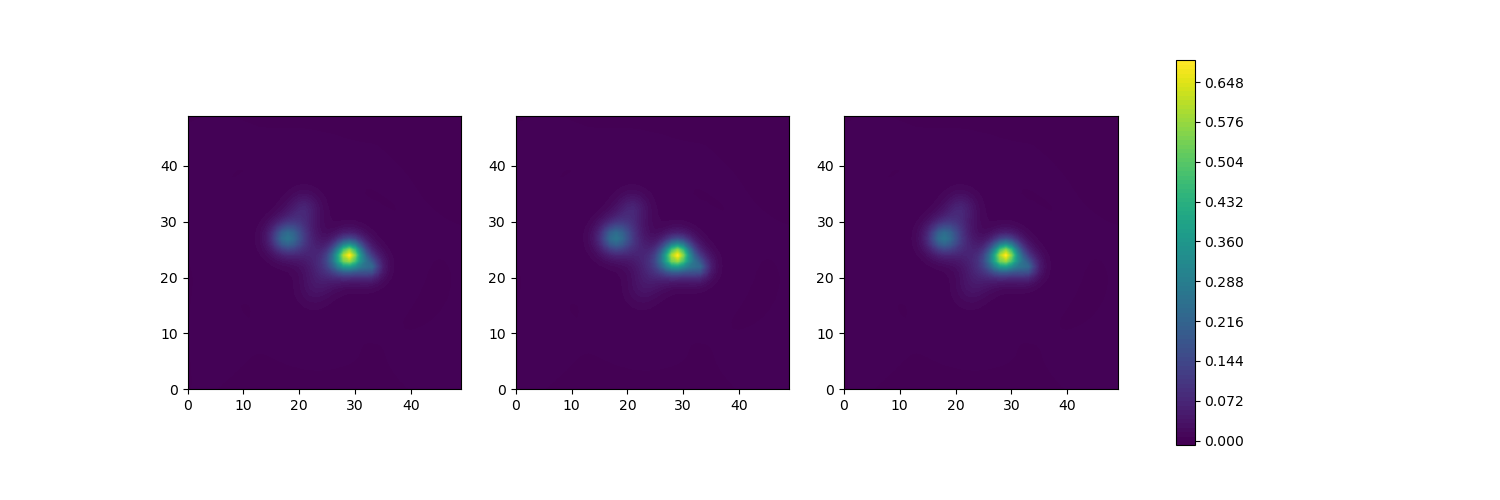

In [44]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131)
x, y  = np.meshgrid(np.arange(50), np.arange(50))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 23
idx = np.ravel_multi_index((x_f, y_f, z_f), (50, 50, 50))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
dens2d = res_density.squeeze().detach().cpu().numpy()[idx]
dens2d = dens2d.reshape(50, 50)
p_dens = sample_df['density'].squeeze()
p_dens = p_dens[idx].reshape(50, 50)
m_dens = res_density_2.squeeze().detach().cpu().numpy()[idx].reshape(50, 50)

indices = np.stack((x_f, y_f, z_f), axis=1)
coords_space = sample['coords']
print('coords space shape', coords_space.shape)
vmin = np.min(np.min(np.concatenate([dens2d, p_dens])))
vmax = np.max(np.max(np.concatenate([dens2d, p_dens])))
print('vmin', vmin)
print('vmax', vmax)
#vmin = np.min(np.min(np.concatenate([dens2d, p_dens`, m_dens])))
#vmax = np.max(np.max(np.concatenate([dens2d, p_dens, m_dens])))
c1 = ax1.contourf(x, y, dens2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')

ax2 = fig.add_subplot(132)
c2 = ax2.contourf(x, y, p_dens, vmin=vmin, vmax=vmax, levels=100)
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
c3 = ax3.contourf(x, y, m_dens, vmin=vmin, vmax=vmax, levels=100)
ax3.set_aspect('equal')

fig.colorbar(c3, ax=[ax1,ax2,ax3])
#fig.colorbar(c1, ax=[ax1,ax2])
#plt.savefig('figures/target_vs_result.pdf', dpi=300)
plt.show()

In [45]:
sample_idx = 2
sample = dataset_df.get_properties([sample_idx])
res = model_1(sample)
#print('df coeffs', res['df_coeffs'])
#print('spherical coeffs', res['spherical_coeffs'])
vec_to_coeff = orbitals.vector_to_coeffs_dict({'spherical_coeffs': res['df_coeffs']}, model_1.density_repr_model[0].orbital_basis,
                                         res['atom_numbers'], radial_coeffs=False)
coeff_to_vec = orbitals.coeffs_dict_to_vector(res, model_1.density_repr_model[0].orbital_basis,
                                         res['atom_numbers'], radial_coeffs=False)['spherical_coeffs']
#print('vector to coeffs', vec_to_coeff)
#print('coeffs to vector', coeff_to_vec)
print('df', torch.all(res['df_coeffs'] == coeff_to_vec))
print('coeff', [[torch.all(res['spherical_coeffs'][i][key] == vec_to_coeff['spherical_coeffs'][i][key]) for key in res['spherical_coeffs'][i].keys()] for i in range(len(res['spherical_coeffs']))])

df tensor(True)
coeff [[tensor(True), tensor(True), tensor(True), tensor(True), tensor(True), tensor(True)], [tensor(True), tensor(True), tensor(True), tensor(True), tensor(True), tensor(True)], [tensor(True), tensor(True), tensor(True), tensor(True), tensor(True), tensor(True)], [tensor(True), tensor(True), tensor(True), tensor(True), tensor(True)], [tensor(True), tensor(True), tensor(True), tensor(True), tensor(True)], [tensor(True), tensor(True), tensor(True), tensor(True), tensor(True)], [tensor(True), tensor(True), tensor(True), tensor(True), tensor(True)], [tensor(True), tensor(True), tensor(True), tensor(True), tensor(True)], [tensor(True), tensor(True), tensor(True), tensor(True), tensor(True)]]


In [12]:
args, hyperparam_args = parse_command_line_arguments(arg_file='ethanethiol_df_001_mae.txt')

print('type dtype', type(args.dtype))
args.fix_arguments = True
print('args np dir', args.np_dataset)
# no restart directory specified
directory = args.restart  # load directory name
# load latest checkpoint
checkpoint_path = os.path.join(directory, 'checkpoints')  # checkpoint directory
checkpoint = torch.load(os.path.join(
    checkpoint_path, 'latest_checkpoint.pth'), map_location='cpu')
latest_checkpoint = checkpoint['step']
model_code = checkpoint['ID']  # load ID
step = checkpoint['step']
for arg in vars(checkpoint['args']):
    if args.fix_arguments:
        if arg in hyperparam_args:
            print('loading hyperparam arg', arg)
            setattr(args, arg, getattr(checkpoint['args'], arg))
    else:
        print('loading all arg', arg)
        setattr(args, arg, getattr(checkpoint['args'], arg))
restore = True

args.best_model_path = 'best_' + model_code + '.pth'
print('best_model_path', args.best_model_path)

print('model code:', model_code)
# determine whether GPU is used for training
print('args use gpu', args.use_gpu)
args.use_gpu = False
# load dataset(s)
print("loading density from" + str(args.dens_dataset) + "...")
print("loading atoms from" + args.np_dataset + "...")

args.radial_coeffs_file = 'datasets/augccpvqzjkfit_radial_coeffs_libcint_df.npy'

args.verbose = 0
args.use_gpu = False
args.cube_grid = False
args.radii_adjust = True 
args.expansion_constraint=None
if args.cube_grid:
    args.cube_origin = -5
    args.cube_extent = 10
    args.cube_size = 50
    args.radii_adjust = False
    grid_origin = args.cube_origin
    grid_extent = np.array([args.cube_extent] * 3)
    grid_fn = partial(cubical_grid, nx=args.cube_size, ny=args.cube_size, nz=args.cube_size,
                      extent=grid_extent,
                      origin=np.array([grid_origin] * 3))
    sampling_fn = cubical_sampling
else:
    args.spherical_grid_level = 4
    grid_fn = partial(spherical_grid, level=args.spherical_grid_level)
    sampling_fn = partial(spherical_radial_sampling, rotate=False)
    grid_origin = 0
    grid_extent = None

    
dataset = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density', 'df_coeffs'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=torch.float32,
                           grid_fn=grid_fn,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           verbose=0,
                           radii_adjust=args.radii_adjust)

dataset_df = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density', 'df_coeffs'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=torch.float32,
                           grid_fn=grid_fn,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           verbose=0,
                           radii_adjust=args.radii_adjust,
                           projected_density=True)
    
#dataset_df.density_fitting[0]['df_coeff'] *= 0
sample = dataset.get_properties([1])
sample_df = dataset_df.get_properties([1])
print(sample['density'].shape)
print(sample_df['density'].shape)
print(sample['coord_weights'].shape)
print(sample['atom_numbers'].shape)
print('density loss', torch.sum(torch.abs(sample['density'] - sample_df['density']) * sample['coord_weights'])/torch.sum(sample['atom_numbers']))
print('density integral', torch.sum(sample['density'] * sample['coord_weights']))
print('df integral', torch.sum(sample_df['density'] * sample['coord_weights']))
args.timing = False
model_1 = load_model(args, dataset)
result = model_1(sample)
print('ml density loss', torch.sum(torch.abs(sample['density'] - result['density']) * sample['coord_weights'])/torch.sum(sample['atom_numbers']))
print('ml density integral', torch.sum(result['density'] * sample['coord_weights']))
args.restart = None
model_2 = load_model(args, dataset)

type dtype <class 'torch.dtype'>
args np dir datasets/ethanethiol_augccpvdz_kcal_train.npy
loading hyperparam arg activation
loading hyperparam arg order
loading hyperparam arg mixing_order
loading hyperparam arg order_en
loading hyperparam arg mixing_order_en
loading hyperparam arg num_features
loading hyperparam arg num_basis_functions
loading hyperparam arg num_radial_components
loading hyperparam arg num_energy_features
loading hyperparam arg num_modules
loading hyperparam arg num_en_modules
loading hyperparam arg num_residual_pre_x
loading hyperparam arg num_residual_post_x
loading hyperparam arg num_residual_pre_vi
loading hyperparam arg num_residual_pre_vj
loading hyperparam arg num_residual_post_v
loading hyperparam arg num_residual_output
loading hyperparam arg num_energy_output
loading hyperparam arg num_neighbours
loading hyperparam arg basis_functions
loading hyperparam arg cutoff
loading hyperparam arg orthonormal_basis
loading hyperparam arg expansion_constraint
loading h

In [13]:

sample_idx = 2
sample_df = dataset_df.get_properties([sample_idx])
df_coeffs = sample['df_coeffs']
df_integral =  torch.sum((sample_df['density']) * sample_df['coord_weights'])
print('df integral', df_integral)
print('df density max', torch.max(sample_df['density']))

permuted_coeffs = transform_df_coeffs.transform(sample_df['df_coeffs'], sample_df['atom_numbers'])

coeffs = orbitals.vector_to_coeffs_dict({'spherical_coeffs': permuted_coeffs}, model_1.density_repr_model[0].orbital_basis,
                                         result['atom_numbers'], radial_coeffs=False)
sample = dataset.get_properties([sample_idx])
sample['spherical_coeffs'] = coeffs['spherical_coeffs']
sample['radial_width'] = [{key:torch.zeros_like(result['radial_width'][i][key]) for key in result['radial_width'][i].keys()} for i in range(len(result['radial_width']))]
sample['radial_scale'] = [{key:torch.zeros_like(result['radial_scale'][i][key]) for key in result['radial_scale'][i].keys()} for i in range(len(result['radial_scale']))]
# sample['radial_scale'] = result['radial_scale']
res = model_1.property_models['density'](sample)
res_density = res['density']
ml_integral = torch.sum((res_density) * sample_df['coord_weights'])
print('ml integral', ml_integral)
ratio = ml_integral/df_integral
# model_res = model(sample)
# model_dens = model_res['density']
print('abs ratio', float(ratio))
print('density diff', torch.mean((res_density - sample_df['density']) * sample['coord_weights']) / df_integral)
print('pred min idx', torch.argmin((res_density)), '; df min idx', torch.argmin((sample_df['density'])), '; model min idx', torch.argmin((res_density)))
print('pred max idx', torch.argmax((res_density)), '; df max idx', torch.argmax((sample_df['density'])), '; model max idx', torch.argmax((res_density)))
print('pred min', torch.min((res_density)), '; df min', torch.min((sample_df['density'])), '; model min', torch.min((res_density)))
print('pred max', torch.max((res_density)), '; df max', torch.max((sample_df['density'])), '; model max', torch.max((res_density)))
print('ratio max', float(torch.max(res_density)/torch.max(sample_df['density'])))
print('density diff max', (torch.max(res_density) - torch.max(sample_df['density'])))
print('ml df loss', torch.sum(torch.abs(sample_df['density'] - res_density) * sample_df['coord_weights'])/torch.sum(sample_df['atom_numbers']))

res = model_2.property_models['density'](sample)
res_density_2 = res['density']
ml_integral = torch.sum((res_density_2) * sample_df['coord_weights'])
print('ml integral', ml_integral)
ratio = ml_integral/df_integral
# model_res = model(sample)
# res_density = model_res['density']
print('abs ratio', float(ratio))
print('density diff', torch.mean((res_density_2 - sample_df['density']) * sample['coord_weights']) / df_integral)
print('pred min idx', torch.argmin((res_density_2)), '; df min idx', torch.argmin((sample_df['density'])), '; model min idx', torch.argmin((res_density_2)))
print('pred max idx', torch.argmax((res_density_2)), '; df max idx', torch.argmax((sample_df['density'])), '; model max idx', torch.argmax((res_density_2)))
print('pred min', torch.min((res_density_2)), '; df min', torch.min((sample_df['density'])), '; model min', torch.min((res_density_2)))
print('pred max', torch.max((res_density_2)), '; df max', torch.max((sample_df['density'])), '; model max', torch.max((res_density_2)))
print('ratio max', float(torch.max(res_density_2)/torch.max(sample_df['density'])))
print('density diff max', (torch.max(res_density_2) - torch.max(sample_df['density'])))
print('ml df loss', torch.sum(torch.abs(sample_df['density'] - res_density_2) * sample_df['coord_weights'])/torch.sum(sample_df['atom_numbers']))

df integral tensor(34.0000)
df density max tensor(2326.9307)
ml integral tensor(34.0000, dtype=torch.float64)
abs ratio 1.000000252996806
density diff tensor(1.2143e-12, dtype=torch.float64)
pred min idx tensor(67878) ; df min idx tensor(67878) ; model min idx tensor(67878)
pred max idx tensor(56220) ; df max idx tensor(56136) ; model max idx tensor(56220)
pred min tensor(-1.1697e-05, dtype=torch.float64) ; df min tensor(-1.1697e-05) ; model min tensor(-1.1697e-05, dtype=torch.float64)
pred max tensor(2326.9310, dtype=torch.float64) ; df max tensor(2326.9307) ; model max tensor(2326.9310, dtype=torch.float64)
ratio max 1.0000001322619005
density diff max tensor(0.0003, dtype=torch.float64)
ml df loss tensor(4.4216e-07, dtype=torch.float64)
ml integral tensor(34.0000, dtype=torch.float64)
abs ratio 1.000000252996806
density diff tensor(1.2143e-12, dtype=torch.float64)
pred min idx tensor(67878) ; df min idx tensor(67878) ; model min idx tensor(67878)
pred max idx tensor(56220) ; df max 

In [30]:
args, hyperparam_args = parse_command_line_arguments(arg_file='water_dyn_spherical_new.txt')

print('type dtype', type(args.dtype))
args.fix_arguments = True
print('args np dir', args.np_dataset)
# no restart directory specified
if args.restart is None:
    # generate "unique" id for the run (very unlikely that two runs will have the same ID)
    # create directories
    checkpoint = None
    latest_checkpoint = 0
    step = 0
    restore = False
    data_split_indices = None
    # restarts run from latest checkpoint
else:
    directory = args.restart  # load directory name
    # load latest checkpoint
    checkpoint_path = os.path.join(directory, 'checkpoints')  # checkpoint directory
    checkpoint = torch.load(os.path.join(
        checkpoint_path, 'latest_checkpoint.pth'), map_location='cpu')
    latest_checkpoint = checkpoint['step']
    model_code = checkpoint['ID']  # load ID
    step = checkpoint['step']
    for arg in vars(checkpoint['args']):
        if args.fix_arguments:
            if arg in hyperparam_args:
                print('loading hyperparam arg', arg)
                setattr(args, arg, getattr(checkpoint['args'], arg))
        else:
            print('loading all arg', arg)
            setattr(args, arg, getattr(checkpoint['args'], arg))
    restore = True
args.use_gpu = False
# load dataset(s)
print("loading density from" + str(args.dens_dataset) + "...")
print("loading atoms from" + args.np_dataset + "...")
args.verbose = 0
args.use_gpu = False
args.radii_adjust = True 
if args.cube_grid:
    grid_origin = args.cube_origin
    grid_extent = np.array([args.cube_extent] * 3)
    grid_fn = partial(cubical_grid, nx=args.cube_size, ny=args.cube_size, nz=args.cube_size,
                      extent=grid_extent,
                      origin=np.array([grid_origin] * 3))
    sampling_fn = cubical_sampling
else:
    grid_fn = partial(spherical_grid, level=2)
    sampling_fn = partial(spherical_radial_sampling, rotate=False)
    grid_origin = 0
    grid_extent = None

args.np_dataset = 'datasets/h2o_dynamic_centered.npy'
args.dens_dataset = 'datasets/h2o_dynamic_pyscf_def2svp_dft_f_augccpvqzjkfit.npy'

dataset = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density', 'df_coeffs'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=torch.float32,
                           grid_fn=grid_fn,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           verbose=0,
                           radii_adjust=args.radii_adjust)

dataset_df = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density', 'df_coeffs'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=torch.float32,
                           grid_fn=grid_fn,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           verbose=0,
                           radii_adjust=args.radii_adjust,
                           projected_density=True)

sample = dataset.get_properties([1])
sample_df = dataset_df.get_properties([1])
print(sample['density'].shape)
print(sample_df['density'].shape)
print(sample['coord_weights'].shape)
print(sample['atom_numbers'].shape)
print('density loss', torch.sum(torch.abs(sample['density'] - sample_df['density']) * sample['coord_weights'])/torch.sum(sample['atom_numbers']))
print('density integral', torch.sum(sample['density'] * sample['coord_weights']))
print('df integral', torch.sum(sample_df['density'] * sample['coord_weights']))
args.timing = False
model_1 = load_model(args, dataset)
result = model_1(sample)
print('ml density loss', torch.sum(torch.abs(sample['density'] - result['density']) * sample['coord_weights'])/torch.sum(sample['atom_numbers']))
print('ml density integral', torch.sum(result['density'] * sample['coord_weights']))
args.restart = None
model_2 = load_model(args, dataset)
print('result df coeffs', result['df_coeffs'])
print('result df weights', result['df_weights'])

type dtype <class 'torch.dtype'>
args np dir datasets/water_combined.npy
loading density fromdatasets/water_combined_pyscf_def2svp_dft_f_augccpvqzjkfit.npy...
loading atoms fromdatasets/water_combined.npy...
finished init
finished init
torch.Size([1, 22324])
torch.Size([1, 22324])
torch.Size([1, 22324])
torch.Size([1, 3])
density loss tensor(0.0078)
density integral tensor(10.0000)
df integral tensor(10.0000)
cg_matrix shape torch.Size([121, 121, 121])
args energy_unit_in hartree
args energy_unit_out kcal
conversions in <function hartree_to_kcal at 0x7fb897f1c598>
conversions out <function kcal_to_kcal at 0x7fb897f1c7b8>
self.pred_radial_coeffs True
building spherical harmonic energy model
self energy order [5, 1, 1]
self energy mixing order [5, 1, 1]
self energy num features 128
idx_i shape torch.Size([6])
ml density loss tensor(9.4184, grad_fn=<DivBackward0>)
ml density integral tensor(101.2188, grad_fn=<SumBackward0>)
cg_matrix shape torch.Size([121, 121, 121])
args energy_unit_in h

In [33]:
args, hyperparam_args = parse_command_line_arguments(arg_file='water_dyn_spherical_new.txt')

print('type dtype', type(args.dtype))
args.fix_arguments = True
print('args np dir', args.np_dataset)
# no restart directory specified
if args.restart is None:
    # generate "unique" id for the run (very unlikely that two runs will have the same ID)
    # create directories
    checkpoint = None
    latest_checkpoint = 0
    step = 0
    restore = False
    data_split_indices = None
    # restarts run from latest checkpoint
else:
    directory = args.restart  # load directory name
    # load latest checkpoint
    checkpoint_path = os.path.join(directory, 'checkpoints')  # checkpoint directory
    checkpoint = torch.load(os.path.join(
        checkpoint_path, 'latest_checkpoint.pth'), map_location='cpu')
    latest_checkpoint = checkpoint['step']
    model_code = checkpoint['ID']  # load ID
    step = checkpoint['step']
    for arg in vars(checkpoint['args']):
        if args.fix_arguments:
            if arg in hyperparam_args:
                print('loading hyperparam arg', arg)
                setattr(args, arg, getattr(checkpoint['args'], arg))
        else:
            print('loading all arg', arg)
            setattr(args, arg, getattr(checkpoint['args'], arg))
    restore = True
args.use_gpu = False
# load dataset(s)
print("loading density from" + str(args.dens_dataset) + "...")
print("loading atoms from" + args.np_dataset + "...")
args.verbose = 0
args.use_gpu = False
args.radii_adjust = True 
if args.cube_grid:
    grid_origin = args.cube_origin
    grid_extent = np.array([args.cube_extent] * 3)
    grid_fn = partial(cubical_grid, nx=args.cube_size, ny=args.cube_size, nz=args.cube_size,
                      extent=grid_extent,
                      origin=np.array([grid_origin] * 3))
    sampling_fn = cubical_sampling
else:
    grid_fn = partial(spherical_grid, level=2)
    sampling_fn = partial(spherical_radial_sampling, rotate=False)
    grid_origin = 0
    grid_extent = None

args.np_dataset = 'datasets/h2o_dynamic_centered.npy'
args.dens_dataset = 'datasets/h2o_dynamic_pyscf_def2svp_dft_f_augccpvqzjkfit.npy'

dataset = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density', 'df_coeffs'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=torch.float32,
                           grid_fn=grid_fn,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           verbose=0,
                           radii_adjust=args.radii_adjust)

dataset_df = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density', 'df_coeffs'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=torch.float32,
                           grid_fn=grid_fn,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           verbose=0,
                           radii_adjust=args.radii_adjust,
                           projected_density=True)

sample = dataset.get_properties([1])
sample_df = dataset_df.get_properties([1])
print(sample['density'].shape)
print(sample_df['density'].shape)
print(sample['coord_weights'].shape)
print(sample['atom_numbers'].shape)
print('density loss', torch.sum(torch.abs(sample['density'] - sample_df['density']) * sample['coord_weights'])/torch.sum(sample['atom_numbers']))
print('density integral', torch.sum(sample['density'] * sample['coord_weights']))
print('df integral', torch.sum(sample_df['density'] * sample['coord_weights']))
args.timing = False
model_1 = load_model(args, dataset)
result = model_1(sample)
print('ml density loss', torch.sum(torch.abs(sample['density'] - result['density']) * sample['coord_weights'])/torch.sum(sample['atom_numbers']))
print('ml density integral', torch.sum(result['density'] * sample['coord_weights']))
args.restart = None
model_2 = load_model(args, dataset)
print('result df coeffs', result['df_coeffs'])
print('result df weights', result['df_weights'])

type dtype <class 'torch.dtype'>
args np dir datasets/water_combined.npy
loading density fromdatasets/water_combined_pyscf_def2svp_dft_f_augccpvqzjkfit.npy...
loading atoms fromdatasets/water_combined.npy...
finished init
finished init
torch.Size([1, 22324])
torch.Size([1, 22324])
torch.Size([1, 22324])
torch.Size([1, 3])
density loss tensor(0.0078)
density integral tensor(10.0000)
df integral tensor(10.0000)
cg_matrix shape torch.Size([121, 121, 121])
args energy_unit_in hartree
args energy_unit_out kcal
conversions in <function hartree_to_kcal at 0x7fb897f1c598>
conversions out <function kcal_to_kcal at 0x7fb897f1c7b8>
self.pred_radial_coeffs True
building spherical harmonic energy model
self energy order [5, 1, 1]
self energy mixing order [5, 1, 1]
self energy num features 128
idx_i shape torch.Size([6])
relevant keys ['spherical_coeffs', 'coeff_weights']
ml density loss tensor(6.0877, grad_fn=<DivBackward0>)
ml density integral tensor(65.7008, grad_fn=<SumBackward0>)
cg_matrix shap

In [34]:
print('dataset radial coeffs', dataset.radial_coeffs)
print('')
print('dataset coeff weights', dataset.coeff_weights)
sample_idx = 2
sample_df = dataset_df.get_properties([sample_idx])
df_coeffs = sample['df_coeffs']
df_integral =  torch.sum((sample_df['density']) * sample_df['coord_weights'])
print('df integral', df_integral)
print('df density max', torch.max(sample_df['density']))

permuted_coeffs = transform_df_coeffs.transform(sample_df['df_coeffs'], sample_df['atom_numbers'])

coeffs = orbitals.vector_to_coeffs_dict({'spherical_coeffs': permuted_coeffs}, model_1.density_repr_model[0].orbital_basis,
                                         result['atom_numbers'], radial_coeffs=False)
sample = dataset.get_properties([sample_idx])
sample['spherical_coeffs'] = coeffs['spherical_coeffs']
sample['radial_width'] = [{key:torch.zeros_like(result['radial_width'][i][key]) for key in result['radial_width'][i].keys()} for i in range(len(result['radial_width']))]
sample['radial_scale'] = [{key:torch.zeros_like(result['radial_scale'][i][key]) for key in result['radial_scale'][i].keys()} for i in range(len(result['radial_scale']))]
# sample['radial_scale'] = result['radial_scale']
res = model_1.property_models['density'](sample)
res_density = res['density']
ml_integral = torch.sum((res_density) * sample_df['coord_weights'])
print('ml integral', ml_integral)
ratio = ml_integral/df_integral
# model_res = model(sample)
# model_dens = model_res['density']
print('abs ratio', float(ratio))
print('density diff', torch.mean((res_density - sample_df['density']) * sample['coord_weights']) / df_integral)
print('pred min idx', torch.argmin((res_density)), '; df min idx', torch.argmin((sample_df['density'])), '; model min idx', torch.argmin((res_density)))
print('pred max idx', torch.argmax((res_density)), '; df max idx', torch.argmax((sample_df['density'])), '; model max idx', torch.argmax((res_density)))
print('pred min', torch.min((res_density)), '; df min', torch.min((sample_df['density'])), '; model min', torch.min((res_density)))
print('pred max', torch.max((res_density)), '; df max', torch.max((sample_df['density'])), '; model max', torch.max((res_density)))
print('ratio max', float(torch.max(res_density)/torch.max(sample_df['density'])))
print('density diff max', (torch.max(res_density) - torch.max(sample_df['density'])))
print('ml df loss', torch.sum(torch.abs(sample_df['density'] - res_density) * sample_df['coord_weights'])/torch.sum(sample_df['atom_numbers']))

res = model_2.property_models['density'](sample)
res_density_2 = res['density']
ml_integral = torch.sum((res_density_2) * sample_df['coord_weights'])
print('ml integral', ml_integral)
ratio = ml_integral/df_integral
# model_res = model(sample)
# res_density = model_res['density']
print('abs ratio', float(ratio))
print('density diff', torch.mean((res_density_2 - sample_df['density']) * sample['coord_weights']) / df_integral)
print('pred min idx', torch.argmin((res_density_2)), '; df min idx', torch.argmin((sample_df['density'])), '; model min idx', torch.argmin((res_density_2)))
print('pred max idx', torch.argmax((res_density_2)), '; df max idx', torch.argmax((sample_df['density'])), '; model max idx', torch.argmax((res_density_2)))
print('pred min', torch.min((res_density_2)), '; df min', torch.min((sample_df['density'])), '; model min', torch.min((res_density_2)))
print('pred max', torch.max((res_density_2)), '; df max', torch.max((sample_df['density'])), '; model max', torch.max((res_density_2)))
print('ratio max', float(torch.max(res_density_2)/torch.max(sample_df['density'])))
print('density diff max', (torch.max(res_density_2) - torch.max(sample_df['density'])))
print('ml df loss', torch.sum(torch.abs(sample_df['density'] - res_density_2) * sample_df['coord_weights'])/torch.sum(sample_df['atom_numbers']))

dataset radial coeffs {8: [(array([1517.8667506]), array([614.38451337])), (array([489.67952008]), array([262.9959011])), (array([176.72118665]), array([122.45640021])), (array([63.79223314]), array([57.02835946])), (array([25.36649913]), array([28.55685817])), (array([9.91354912]), array([14.11519546])), (array([4.46453066]), array([7.75973485])), (array([1.80177437]), array([3.92907508])), (array([0.80789711]), array([2.15294069])), (array([0.33864327]), array([1.12155832])), (array([0.14194786]), array([0.58426741])), (array([120.16030921]), array([1160.6083455])), (array([34.40962247]), array([243.12760793])), (array([12.58114861]), array([69.1249385])), (array([5.06638242]), array([22.17465403])), (array([2.03469271]), array([7.08937466])), (array([0.86092967]), array([2.41932374])), (array([0.36681357]), array([0.8328008])), (array([0.15628709]), array([0.28667398])), (array([19.04306281]), array([452.96931782])), (array([5.80603811]), array([56.66555931])), (array([2.18918416]),